In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r'C:\Users\abhi1\OneDrive\Desktop\datasets\grocery_chain_data.csv')
df_original = df.copy()

print("=== DATASET INFO ===")
df_original.info()

print("\n=== FIRST 5 ROWS ===")
print(df_original.head())

print("\n=== NULL VALUES ===")
print(df_original.isnull().sum())

print("\n=== DATASET STATISTICS ===")
print(df_original.describe())

print("\n=== DUPLICATED ROWS ===")
print(df.duplicated().sum())

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       1980 non-null   int64  
 1   store_name        1955 non-null   object 
 2   transaction_date  1980 non-null   object 
 3   aisle             1980 non-null   object 
 4   product_name      1980 non-null   object 
 5   quantity          1980 non-null   float64
 6   unit_price        1980 non-null   float64
 7   total_amount      1980 non-null   float64
 8   discount_amount   1980 non-null   float64
 9   final_amount      1980 non-null   float64
 10  loyalty_points    1980 non-null   int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 170.3+ KB

=== FIRST 5 ROWS ===
   customer_id         store_name transaction_date           aisle  \
0         2824  GreenGrocer Plaza       2023-08-26         Produce   
1         5506   ValuePlus Market  

In [5]:
print("\n=== DATA CLEANING ===")

# Convert transaction_date to Datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Fill null values in store_name with most common store name
df['store_name'].fillna(df['store_name'].mode()[0], inplace=True)

# Drop customer_id column (not needed for analysis)
df = df.drop('customer_id', axis=1)

print("=== CLEANED DATASET INFO ===")
df.info()

print("\n=== NULL VALUES AFTER CLEANING ===")
print(df.isnull().sum())


=== DATA CLEANING ===
=== CLEANED DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   store_name        1980 non-null   object        
 1   transaction_date  1980 non-null   datetime64[ns]
 2   aisle             1980 non-null   object        
 3   product_name      1980 non-null   object        
 4   quantity          1980 non-null   float64       
 5   unit_price        1980 non-null   float64       
 6   total_amount      1980 non-null   float64       
 7   discount_amount   1980 non-null   float64       
 8   final_amount      1980 non-null   float64       
 9   loyalty_points    1980 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1), object(3)
memory usage: 154.8+ KB

=== NULL VALUES AFTER CLEANING ===
store_name          0
transaction_date    0
aisle               0
product_


=== REVENUE ANALYSIS ===
Total Gross Revenue: 90887.1


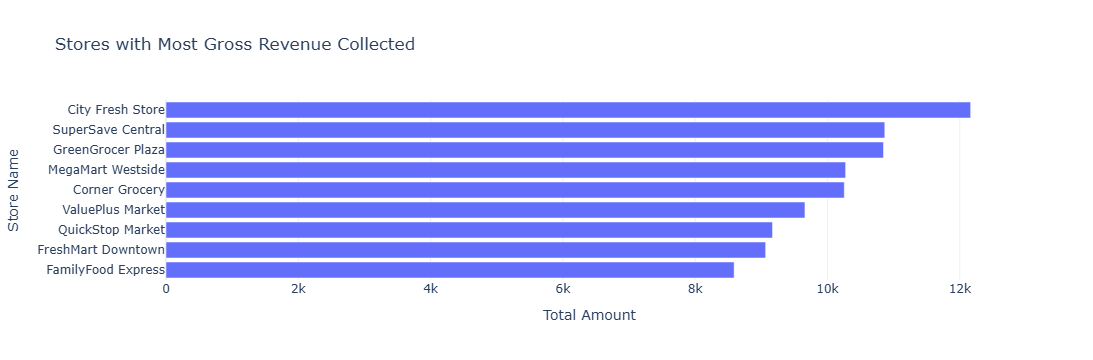

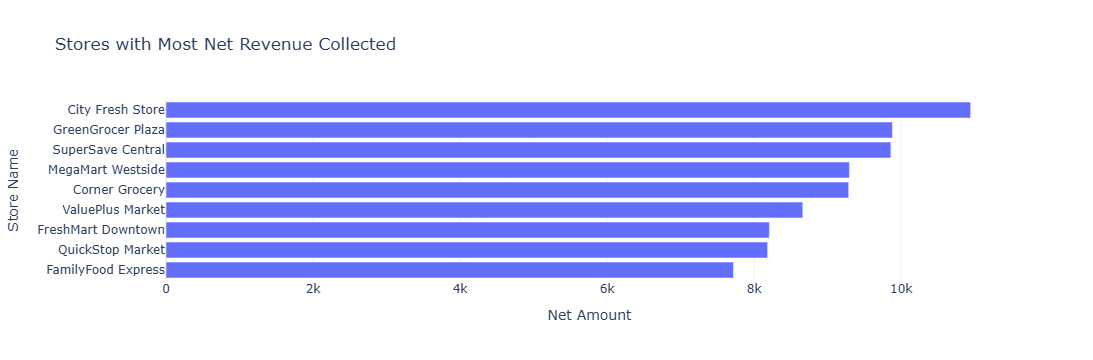

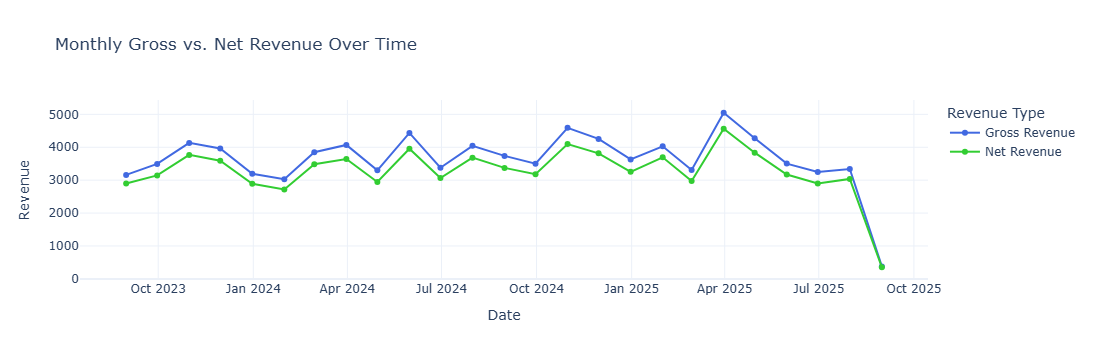

In [6]:
print("\n=== REVENUE ANALYSIS ===")

# 1. Total Revenue
total_revenue = df['total_amount'].sum()
print(f"Total Gross Revenue: {total_revenue}")

# 2. Revenue Collected By Store
# Gross Revenue
store_revenue_gross = df.groupby('store_name')['total_amount'].sum().sort_values(ascending=False).reset_index()

fig = px.bar(
    store_revenue_gross,
    y='store_name',
    x='total_amount',
    title='Stores with Most Gross Revenue Collected',
    labels={'store_name': 'Store Name', 'total_amount': 'Total Amount'},
    template='plotly_white',
    orientation='h'
)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.write_html("C:\\Users\\abhi1\\store_gross_revenue.html")
fig.show()

# Net Revenue
store_revenue_net = df.groupby('store_name')['final_amount'].sum().sort_values(ascending=False).reset_index()

fig = px.bar(
    store_revenue_net,
    y='store_name',
    x='final_amount',
    title='Stores with Most Net Revenue Collected',
    labels={'store_name': 'Store Name', 'final_amount': 'Net Amount'},
    template='plotly_white',
    orientation='h'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.write_html("C:\\Users\\abhi1\\store_net_revenue.html")
fig.show()

# 3. Revenue Over Time
monthly_revenue = df.set_index('transaction_date').resample('M')[['total_amount', 'final_amount']].sum().reset_index()

fig = go.Figure()

# Gross Revenue
fig.add_trace(go.Scatter(
    x=monthly_revenue['transaction_date'],
    y=monthly_revenue['total_amount'],
    mode='lines+markers',
    name='Gross Revenue',
    line=dict(color='royalblue')
))

# Net Revenue
fig.add_trace(go.Scatter(
    x=monthly_revenue['transaction_date'],
    y=monthly_revenue['final_amount'],
    mode='lines+markers',
    name='Net Revenue',
    line=dict(color='limegreen')
))

fig.update_layout(
    title='Monthly Gross vs. Net Revenue Over Time',
    xaxis_title='Date',
    yaxis_title='Revenue',
    template='plotly_white',
    legend=dict(title='Revenue Type')
)
fig.write_html("C:\\Users\\abhi1\\monthly_revenue_over_time.html")
fig.show()


=== DISCOUNT ANALYSIS ===


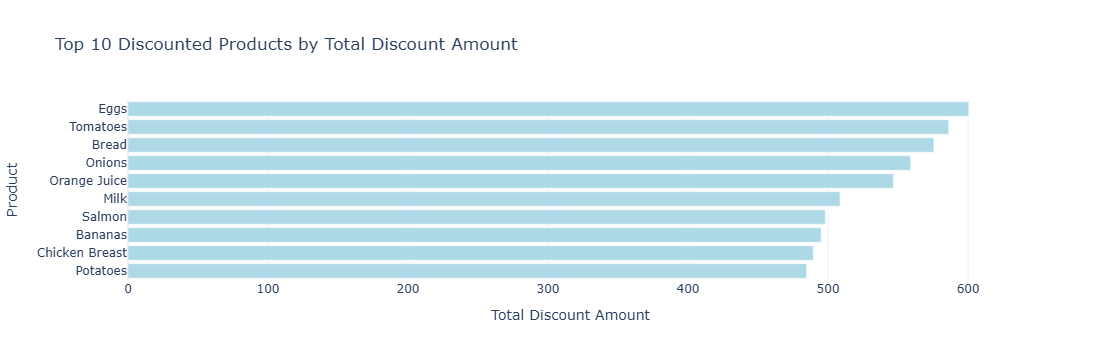

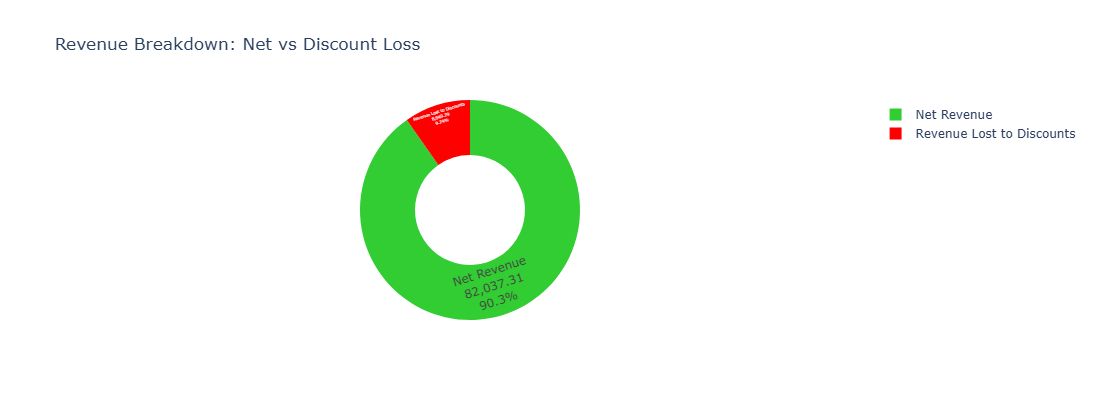

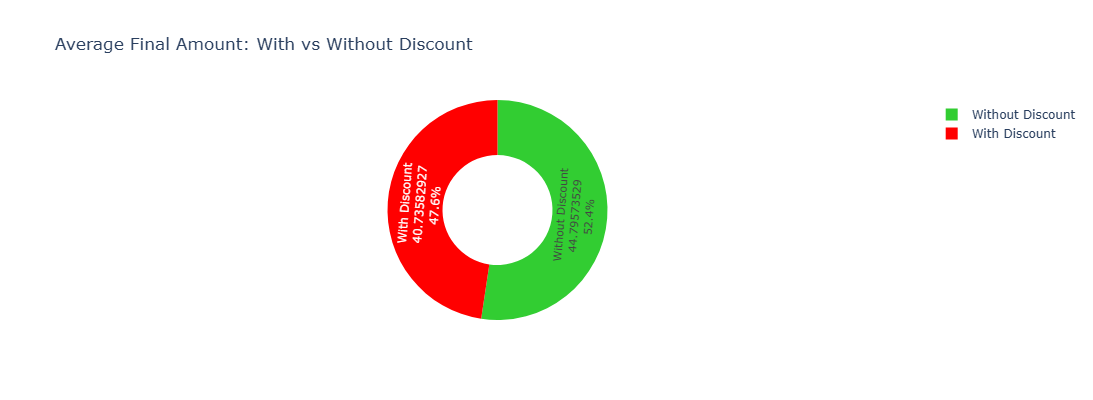


Top 10 Aisles by Discount Loss:
                aisle  total_discount  total_revenue  net_revenue  \
10     Snacks & Candy          947.39        9014.34      8066.95   
1           Beverages          928.72        8748.97      7820.25   
8       Personal Care          871.78        9160.90      8289.12   
2        Canned Goods          871.01        8917.59      8046.58   
3               Dairy          801.71        8184.91      7383.20   
4        Frozen Foods          795.27        7973.12      7177.85   
0              Bakery          752.12        8313.37      7561.25   
6     Household Items          747.99        7648.27      6900.28   
5   Health & Wellness          733.81        8639.25      7905.44   
7      Meat & Seafood          720.06        7511.27      6791.21   

    discount_percent  
10         10.509810  
1          10.615192  
8           9.516314  
2           9.767325  
3           9.794976  
4           9.974389  
0           9.047113  
6           9.779859  


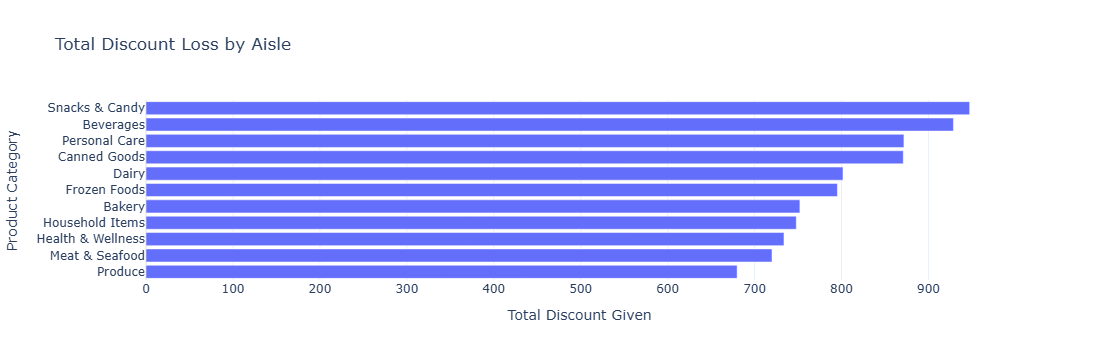

In [7]:
print("\n=== DISCOUNT ANALYSIS ===")

# 1. Top Discounted Products
top_discounted_products = df.groupby('product_name').agg(
    total_discount=('discount_amount', 'sum'),
    total_revenue=('total_amount', 'sum'),
    discount_rate_percent=('discount_amount', lambda x: 100 * x.sum() / x.count())
).sort_values(by='total_discount', ascending=False).head(10).reset_index()

fig = px.bar(
    top_discounted_products,
    x='total_discount',
    y='product_name',
    orientation='h',
    title='Top 10 Discounted Products by Total Discount Amount',
    template='plotly_white',
    labels={'total_discount': 'Total Discount Amount', 'product_name': 'Product'},
    hover_data=['total_revenue', 'discount_rate_percent']
)
fig.update_traces(marker_color='lightblue')
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.write_html("C:\\Users\\abhi1\\top_discounted_products.html")
fig.show()

# 2. Total Revenue Before and After Discount
gross_revenue = df['total_amount'].sum()
net_revenue = df['final_amount'].sum()
revenue_loss = gross_revenue - net_revenue

fig = px.pie(
    names=['Net Revenue', 'Revenue Lost to Discounts'],
    values=[net_revenue, revenue_loss],
    title='Revenue Breakdown: Net vs Discount Loss',
    template='plotly_white',
    hole=0.5,
    color_discrete_sequence=['limegreen', 'red'],
    height=400,
    width=700
)
fig.update_traces(textposition='inside', textinfo='label+percent+value')
fig.write_html("C:\\Users\\abhi1\\revenue_breakdown_pie.html")
fig.show()

# 3. Discount Efficiency: Is Discount Driving Higher Orders?
with_discount = df[df['discount_amount'] > 0]['final_amount'].mean()
without_discount = df[df['discount_amount'] == 0]['final_amount'].mean()

fig = px.pie(
    names=['With Discount', 'Without Discount'],
    values=[with_discount, without_discount],
    title='Average Final Amount: With vs Without Discount',
    template='plotly_white',
    hole=0.5,
    color_discrete_sequence=['limegreen', 'red'],
    height=400,
    width=700
)
fig.update_traces(textposition='inside', textinfo='label+percent+value')
fig.write_html("C:\\Users\\abhi1\\discount_efficiency_pie.html")
fig.show()

# 4. Product Categories (Aisles) Driving Most Discount Losses
aisle_discount = df.groupby('aisle').agg(
    total_discount=('discount_amount', 'sum'),
    total_revenue=('total_amount', 'sum'),
    net_revenue=('final_amount', 'sum')
).reset_index()

aisle_discount['discount_percent'] = (aisle_discount['total_discount'] / aisle_discount['total_revenue']) * 100
aisle_discount = aisle_discount.sort_values(by='total_discount', ascending=False)

print("\nTop 10 Aisles by Discount Loss:")
print(aisle_discount.head(10))

fig = px.bar(
    aisle_discount,
    y='aisle',
    x='total_discount',
    title='Total Discount Loss by Aisle',
    labels={'aisle': 'Product Category', 'total_discount': 'Total Discount Given'},
    template='plotly_white',
    orientation='h'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.write_html("C:\\Users\\abhi1\\aisle_discount_loss.html")
fig.show()



=== PRODUCT & AISLE INSIGHTS ===


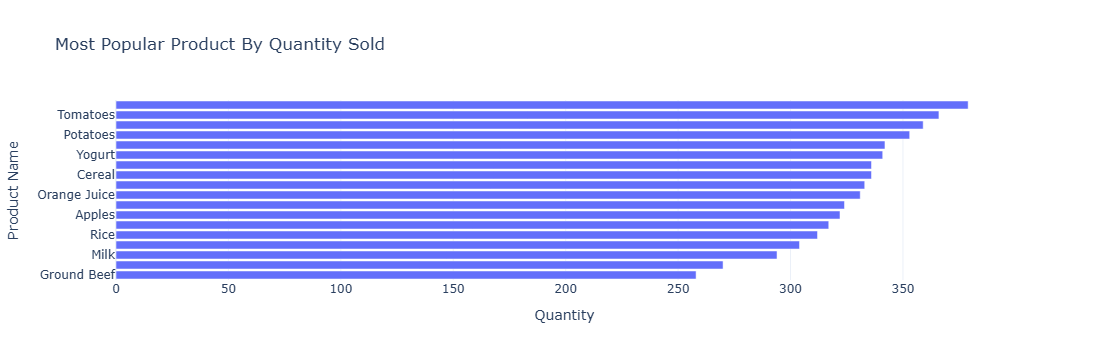

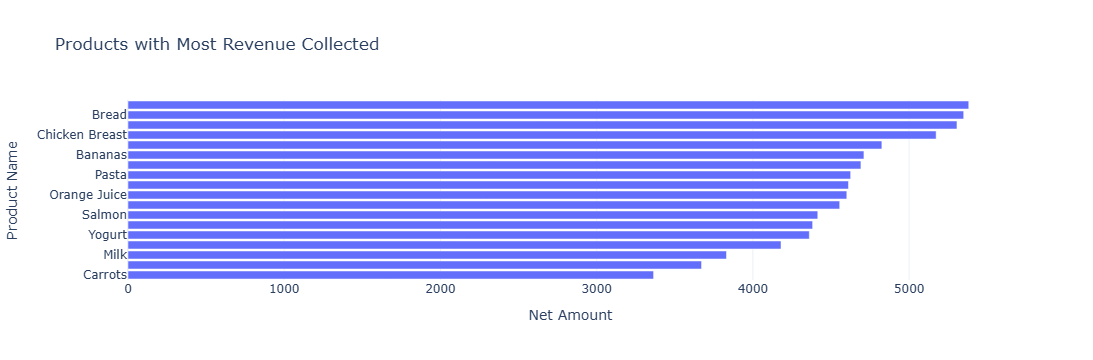

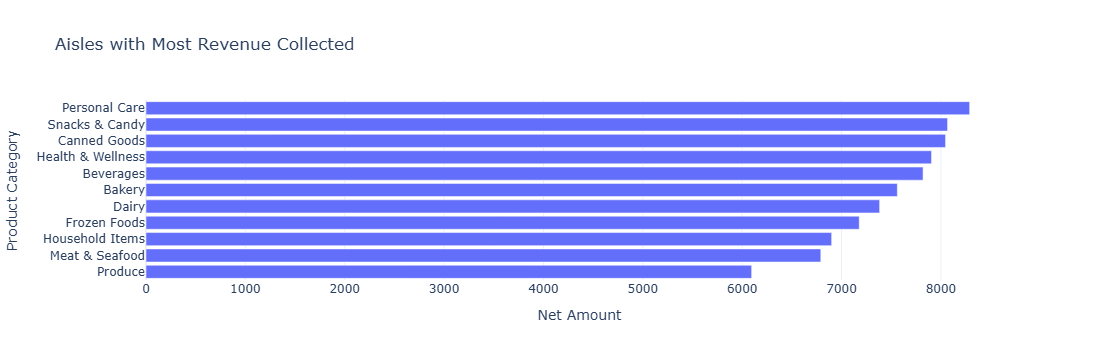


Top 10 Profitable Products per Unit:
   product_name  total_quantity  total_revenue  revenue_per_unit
12        Pasta           304.0        4625.74         15.216250
13     Potatoes           353.0        5306.25         15.031870
2         Bread           359.0        5349.36         14.900724
1       Bananas           317.0        4710.76         14.860442
16     Tomatoes           366.0        5381.71         14.704126
7          Eggs           333.0        4825.59         14.491261
8   Ground Beef           258.0        3671.27         14.229729
0        Apples           322.0        4555.64         14.147950
14         Rice           312.0        4382.43         14.046250
4        Cereal           336.0        4691.40         13.962500


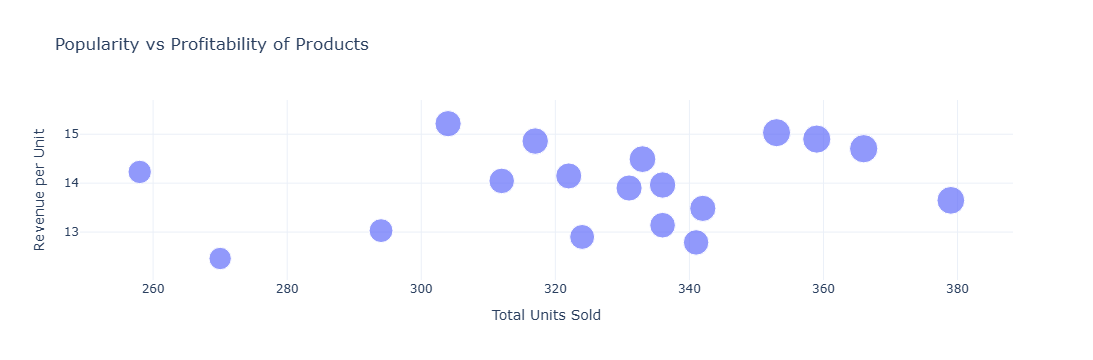

In [8]:
print("\n=== PRODUCT & AISLE INSIGHTS ===")

# 1. Most Popular Product By Quantity Sold
popular_product = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).reset_index()

fig = px.bar(
    popular_product,
    y='product_name',
    x='quantity',
    title='Most Popular Product By Quantity Sold',
    labels={'product_name': 'Product Name', 'quantity': 'Quantity'},
    template='plotly_white',
    orientation='h'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.write_html("C:\\Users\\abhi1\\popular_product_quantity.html")
fig.show()

# 2. Most Profitable Product
profitable_product = df.groupby('product_name')['final_amount'].sum().sort_values(ascending=False).reset_index()

fig = px.bar(
    profitable_product,
    y='product_name',
    x='final_amount',
    title='Products with Most Revenue Collected',
    labels={'product_name': 'Product Name', 'final_amount': 'Net Amount'},
    template='plotly_white',
    orientation='h'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.write_html("C:\\Users\\abhi1\\most_profitable_product.html")
fig.show()

# 3. Top aisles by sales
profitable_aisles = df.groupby('aisle')['final_amount'].sum().sort_values(ascending=False).reset_index()

fig = px.bar(
    profitable_aisles,
    y='aisle',
    x='final_amount',
    title='Aisles with Most Revenue Collected',
    labels={'aisle': 'Product Category', 'final_amount': 'Net Amount'},
    template='plotly_white',
    orientation='h'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.write_html("C:\\Users\\abhi1\\top_aisles_sales.html")
fig.show()

# 4. Revenue Per Unit Sold (Profitability vs Popularity)
product_analysis = df.groupby('product_name').agg(
    total_quantity=('quantity', 'sum'),
    total_revenue=('final_amount', 'sum')
).reset_index()

product_analysis['revenue_per_unit'] = product_analysis['total_revenue'] / product_analysis['total_quantity']
product_analysis = product_analysis.sort_values(by='revenue_per_unit', ascending=False)

print("\nTop 10 Profitable Products per Unit:")
print(product_analysis.head(10))

fig = px.scatter(
    product_analysis,
    x='total_quantity',
    y='revenue_per_unit',
    size='total_revenue',
    hover_name='product_name',
    title='Popularity vs Profitability of Products',
    labels={'total_quantity': 'Total Units Sold', 'revenue_per_unit': 'Revenue per Unit'},
    template='plotly_white'
)
fig.write_html("C:\\Users\\abhi1\\popularity_vs_profitability.html")
fig.show()



=== TIME BASED ANALYSIS ===


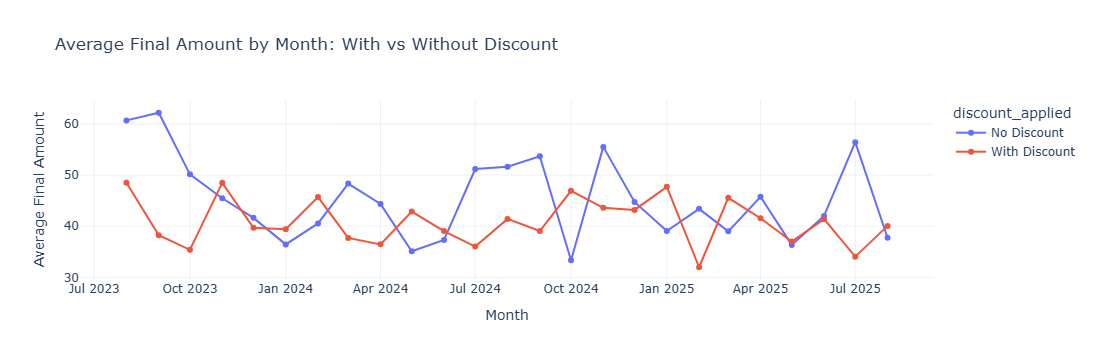

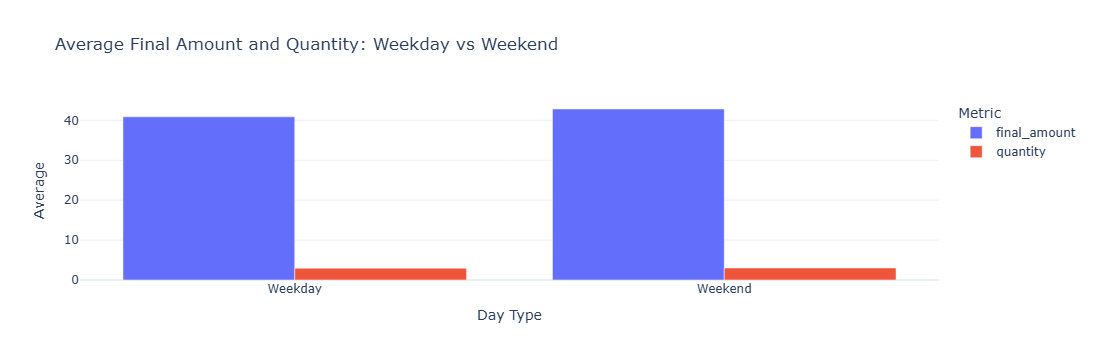

In [9]:
print("\n=== TIME BASED ANALYSIS ===")

# 1. Final Amount with and without discount for each Month
df['discount_applied'] = df['discount_amount'] > 0

monthly_avg = (
    df.groupby([df['transaction_date'].dt.to_period('M'), 'discount_applied'])['final_amount']
      .mean()
      .reset_index()
)

monthly_avg['transaction_date'] = monthly_avg['transaction_date'].dt.to_timestamp()

monthly_avg['discount_applied'] = monthly_avg['discount_applied'].map({
    True: 'With Discount',
    False: 'No Discount'
})

fig = px.line(
    monthly_avg,
    x='transaction_date',
    y='final_amount',
    color='discount_applied',
    markers=True,
    title='Average Final Amount by Month: With vs Without Discount',
    labels={'final_amount': 'Average Final Amount', 'transaction_date': 'Month'},
    template='plotly_white'
)
fig.write_html("C:\\Users\\abhi1\\monthly_avg_discount.html")
fig.show()

# 2. Average final_amount or quantity between weekdays and weekends
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['weekday_type'] = df['day_of_week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

avg_values = (
    df.groupby('weekday_type')[['final_amount', 'quantity']]
      .mean()
      .reset_index()
)

avg_melted = avg_values.melt(id_vars='weekday_type', value_vars=['final_amount', 'quantity'],
                              var_name='Metric', value_name='Average')

fig = px.bar(
    avg_melted,
    x='weekday_type',
    y='Average',
    color='Metric',
    barmode='group',
    title='Average Final Amount and Quantity: Weekday vs Weekend',
    labels={'weekday_type': 'Day Type'},
    template='plotly_white'
)
fig.write_html("C:\\Users\\abhi1\\weekday_vs_weekend.html")
fig.show()

In [10]:
print("\n" + "="*60)
print("GROCERY CHAIN DATA ANALYSIS - SUMMARY")
print("="*60)
print(f"Total Transactions: {len(df)}")
print(f"Total Gross Revenue: {gross_revenue:.2f}")
print(f"Total Net Revenue: {net_revenue:.2f}")
print(f"Revenue Lost to Discounts: {revenue_loss:.2f} ({revenue_loss/gross_revenue*100:.1f}%)")
print(f"Number of Stores: {df['store_name'].nunique()}")
print(f"Number of Aisles: {df['aisle'].nunique()}")
print(f"Number of Products: {df['product_name'].nunique()}")
print(f"Average Loyalty Points: {df['loyalty_points'].mean():.2f}")
print("="*60)
print("\nAll visualization charts saved to: C:\\Users\\abhi1\\")




GROCERY CHAIN DATA ANALYSIS - SUMMARY
Total Transactions: 1980
Total Gross Revenue: 90887.10
Total Net Revenue: 82037.31
Revenue Lost to Discounts: 8849.79 (9.7%)
Number of Stores: 9
Number of Aisles: 11
Number of Products: 18
Average Loyalty Points: 255.15

All visualization charts saved to: C:\Users\abhi1\
